<a href="https://colab.research.google.com/github/kkokay07/LLM_adaptation/blob/main/Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creator: Dr. KANAKA K. K.
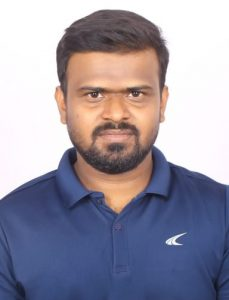

PhD, ARS  
Scientist

School of Bioinformatics and Computational Biology

ICAR-Indian Institute of Agricultural Biotechnology, Ranchi, Jharkhand.

Spy on me at :)  
[Google Scholar](https://scholar.google.com/citations?hl=en&user=0dQ7Sf8AAAAJ&view_op=list_works);    [ResearchGate](https://www.researchgate.net/profile/Kanaka-K-K/research);    [Website](https://iiab.icar.gov.in/staff/dr-kanaka-k-k/)

## 📘 Source

Natural Language Processing with Transformers  
Lewis Tunstall, Leandro von Werra, Thomas Wolf  
O’Reilly Media  

https://www.oreilly.com/library/view/natural-language-processing/9781098136789/

# 🔧 Practical 2: Fine-Tuning an LLM
### Fundamentals of Generative AI — Hands-On Workshop

---

## 📋 What You'll Learn
1. What is fine-tuning and when to use it
2. The difference between pre-training, fine-tuning, and inference
3. How to prepare a custom dataset
4. Fine-tuning DistilGPT-2 on custom agricultural text
5. Comparing outputs before vs after fine-tuning
6. Understanding loss curves and training metrics

**Model Used:** `distilgpt2` (~120MB) — perfect for Colab Free T4 GPU

---

> ⚠️ **Before starting:** Go to `Runtime → Change runtime type → T4 GPU`

---
## 🧠 Concept: What is Fine-Tuning?

```
LARGE PRE-TRAINED MODEL          FINE-TUNED MODEL
(trained on internet text)  →→→  (specialized for your domain)

General knowledge               Domain-specific knowledge
Knows everything, deeply        Knows your topic very well
           ↑                               ↑
   Base Model (DistilGPT2)      Your Fine-Tuned Model
```

**Why Fine-Tune?**
- Adapt model to your domain vocabulary (e.g., agriculture, biotech)
- Teach specific writing style or format
- Improve performance on narrow tasks without full retraining

## 🔧 Step 1: Install Dependencies

In [ ]:
!pip install transformers datasets accelerate -q
print('✅ Dependencies installed!')

Installs three libraries silently (`-q` = quiet, no verbose output):

- **`transformers`** — HuggingFace library; provides models, tokenizers, `Trainer`, `TrainingArguments`
- **`datasets`** — HuggingFace library; provides `Dataset.from_dict()`, `.map()` for data prep
- **`accelerate`** — HuggingFace library; enables GPU/mixed-precision training behind the scenes (required by `Trainer`)

In [ ]:
import torch
import math
import matplotlib.pyplot as plt
from transformers import (
    GPT2LMHeadModel,
    GPT2TokenizerFast,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments

)
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

**Imports explained:**

- **`torch`** — PyTorch; handles tensors, GPU ops, `torch.cuda.is_available()`
- **`math`** — standard Python; used for `math.exp()` to calculate perplexity
- **`matplotlib.pyplot`** — plotting library; draws loss curves
- **`GPT2LMHeadModel`** — GPT-2 with a language modelling head (predicts next token)
- **`GPT2TokenizerFast`** — fast Rust-based tokenizer; converts text ↔ token IDs
- **`DataCollatorForLanguageModeling`** — batches tokens and creates labels for LM training
- **`Trainer`** — HuggingFace training loop; handles epochs, backprop, saving
- **`TrainingArguments`** — config object passed to `Trainer` (LR, epochs, batch size etc.)
- **`Dataset`** — HuggingFace dataset class; replaces deprecated `TextDataset`
- **`warnings.filterwarnings('ignore')`** — suppresses non-critical warnings in output

**Device detection block:**
```python
device = 'cuda' if torch.cuda.is_available() else 'cpu'
```
- Checks if GPU is available; falls back to CPU
- `torch.cuda.get_device_name(0)` — prints GPU model (e.g. `Tesla T4`)
- `.total_memory / 1e9` — converts bytes → GB

## 📦 Step 2: Load the Pre-Trained Model
First, let's see what the base model generates BEFORE fine-tuning.

In [ ]:
print('⏳ Loading DistilGPT-2 base model...')
model_name = 'distilgpt2'

tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

base_model = GPT2LMHeadModel.from_pretrained(model_name)
base_model = base_model.to(device)

print('✅ Base model loaded!')
params = sum(p.numel() for p in base_model.parameters()) / 1e6
print(f'   Parameters: {params:.0f}M')

- **`model_name = 'distilgpt2'`** — HuggingFace model ID; downloaded automatically on first run

- **`.from_pretrained(model_name)`** — downloads and loads pre-trained weights from HuggingFace Hub

- **`tokenizer.pad_token = tokenizer.eos_token`** — GPT-2 has no padding token by default; reusing the end-of-sequence token (`<|endoftext|>`) as padding to avoid errors during batching

- **`base_model.to(device)`** — moves model weights to GPU (`cuda`) if available; stays on CPU otherwise

- **`p.numel()`** — returns number of elements in a tensor (one parameter)
- **`sum(...) / 1e6`** — totals all parameters, divides by 1 million → prints as `82M`

In [ ]:
def generate_text(model, prompt, max_new_tokens=100, temperature=0.8, top_p=0.9):
    """Generate text using the model"""
    model.eval()
    inputs = tokenizer(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Test BEFORE fine-tuning
test_prompt = 'The ICAR research institute developed a new variety of'
print('📝 Prompt:', test_prompt)
print()
print('🤖 BASE MODEL output (before fine-tuning):')
print(generate_text(base_model, test_prompt))
print()
print('💡 Notice: The output may be generic / off-topic / not agriculture-specific')

- **`model.eval()`** — switches model to evaluation mode; disables dropout layers so output is deterministic

- **`tokenizer(prompt, return_tensors='pt')`** — converts text → PyTorch tensor of token IDs
- **`.to(device)`** — moves input tensor to same device as model (GPU/CPU)

- **`torch.no_grad()`** — disables gradient computation; saves memory during inference

- **`model.generate(**inputs, ...)`** — runs the actual text generation with:
  - `max_new_tokens` — max tokens to generate
  - `temperature=0.8` — slight randomness (1.0=neutral, <1=focused, >1=creative)
  - `top_p=0.9` — nucleus sampling; only considers top 90% probability tokens
  - `do_sample=True` — enables probabilistic sampling (vs greedy/beam search)
  - `pad_token_id` — prevents warning about missing pad token

- **`tokenizer.decode(outputs[0], skip_special_tokens=True)`** — converts token IDs back to readable string; `outputs[0]` gets first (only) sequence from batch

---
## 📚 Step 3: Prepare Custom Dataset

We'll create a small agricultural/biotechnology dataset for fine-tuning.

**In real research:** You'd use 1000s of sentences from papers, reports, etc.  
**For demo:** We use ~60 sentences to see the concept in action.

In [ ]:
# Custom domain-specific training data
# In practice, collect from: research papers, ICAR reports, Krishi Vigyan publications

training_texts = [
    # Crop science
    "ICAR scientists developed a high-yielding drought-tolerant variety of wheat suitable for rainfed conditions.",
    "The new paddy variety IR-64 showed resistance to bacterial leaf blight and produced 8 tonnes per hectare.",
    "Chickpea varieties developed at ICRISAT exhibit tolerance to terminal drought through deep root architecture.",
    "The ICAR-IIWBR released HD-3226 wheat variety with improved grain protein content and baking quality.",
    "Hybrid maize varieties developed by CIMMYT showed 30 percent yield advantage over open-pollinated varieties.",
    "Basmati rice varieties from Taraori have unique aroma due to the presence of 2-acetyl-1-pyrroline compound.",
    "Soybean varieties with high oleic acid content were developed using traditional plant breeding methods.",
    "Cotton hybrid Bt-11 incorporates insecticidal protein genes from Bacillus thuringiensis for bollworm resistance.",
    "Mustard hybrid DMH-11 was developed using barnase and barstar system for cytoplasmic male sterility.",
    "Sunflower varieties resistant to downy mildew disease were developed through marker-assisted backcross breeding.",

    # Biotechnology
    "CRISPR-Cas9 gene editing technology has enabled precise modifications in crop genomes without foreign DNA.",
    "Agrobacterium-mediated transformation is widely used for developing transgenic plants in research.",
    "Tissue culture techniques allow rapid multiplication of disease-free planting material in banana and potato.",
    "Molecular markers like SSR and SNP are used in marker-assisted selection for crop improvement programs.",
    "Genomic selection uses whole-genome marker data to predict breeding values for complex quantitative traits.",
    "RNA interference technology silences specific genes and has been used to develop virus-resistant papaya.",
    "Hairy root transformation system is used to produce secondary metabolites in medicinal plant research.",
    "Somaclonal variation arising from tissue culture can be a source of novel genetic diversity in crops.",
    "Embryo rescue technique is used to recover interspecific hybrids where post-fertilization barriers exist.",
    "Flow cytometry is used to determine ploidy levels in plant breeding and polyploidization experiments.",

    # Machine learning in agriculture
    "Deep learning models trained on leaf images can detect plant diseases with over 95 percent accuracy.",
    "Convolutional neural networks are used for automated counting of insects in crop fields using drone imagery.",
    "Random forest models predict crop yield using soil parameters, weather data, and satellite NDVI values.",
    "Recurrent neural networks model time-series rainfall data to forecast drought periods in semi-arid regions.",
    "Transfer learning from ImageNet pretrained models accelerates training for plant disease detection tasks.",
    "Support vector machines classify soil types based on spectral data from hyperspectral remote sensing.",
    "Natural language processing extracts experimental data from agricultural research papers automatically.",
    "Federated learning enables training AI models across multiple farms without sharing raw farm data.",
    "Generative adversarial networks synthesize augmented training images for rare plant disease conditions.",
    "Explainable AI techniques help agronomists understand why machine learning models make specific predictions.",

    # Soil science
    "Soil organic carbon content is a key indicator of soil health and plays a vital role in nutrient cycling.",
    "Rhizobium bacteria form symbiotic associations with legume roots and fix atmospheric nitrogen for plant use.",
    "Mycorrhizal fungi enhance phosphorus uptake in plants by extending the root system into the soil.",
    "Vermicompost improves soil structure, water holding capacity, and provides slow-release nutrients to crops.",
    "Biofertilizers containing Azospirillum reduce nitrogen fertilizer requirement in rice by up to 25 percent.",

    # Climate and environment
    "Climate change is altering crop growing seasons and increasing the frequency of extreme weather events.",
    "Heat stress during anthesis causes significant yield loss in wheat grown in tropical and subtropical regions.",
    "Carbon sequestration in agricultural soils can offset greenhouse gas emissions from farming operations.",
    "Agroforestry systems integrating trees with crops provide ecosystem services and improve farm biodiversity.",
    "Precision irrigation using soil moisture sensors reduces water use by 40 percent without reducing yield.",

    # Research methods
    "Multi-environment trials help breeders identify stable and high-performing crop varieties across locations.",
    "GxE interaction analysis separates genotypic and environmental contributions to observed phenotypic variation.",
    "Next-generation sequencing technologies have reduced the cost of whole genome sequencing dramatically.",
    "Phenomics platforms use automated imaging to measure plant growth traits at high throughput in field conditions.",
    "Bioinformatics pipelines process raw sequencing reads to identify genomic variants associated with traits.",
    "GWAS studies identify SNP markers significantly associated with complex quantitative traits in large populations.",
    "Speed breeding techniques reduce the generation time of crops from months to weeks under controlled lighting.",
    "Participatory variety selection involves farmers in evaluating new crop varieties under their own field conditions.",
    "On-farm trials conducted across diverse agro-ecological zones validate new agricultural technologies effectively.",
    "Meta-analysis of multiple crop trial datasets improves statistical power for detecting small genetic effects.",
]

print(f'✅ Training dataset created: {len(training_texts)} sentences')
print(f'\n📄 Sample sentences:')
for i, t in enumerate(training_texts[:3]):
    print(f'  {i+1}. {t}')

In [ ]:
# Save training data to a text file (required by TextDataset)
training_file = '/content/train.txt'

with open(training_file, 'w') as f:
    for text in training_texts:
        f.write(text + '\n')

print(f'✅ Training file saved to: {training_file}')

# Visualize token length distribution
lengths = [len(tokenizer.encode(t)) for t in training_texts]
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=15, color='steelblue', edgecolor='white')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.title('Token Length Distribution of Training Sentences')
plt.axvline(sum(lengths)/len(lengths), color='red', linestyle='--', label=f'Mean={sum(lengths)/len(lengths):.0f}')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Average tokens per sentence: {sum(lengths)/len(lengths):.1f}')

---
## ⚙️ Step 4: Create Dataset & Data Collator

In [ ]:
# ✅ Modern replacement for TextDataset using datasets.Dataset

BLOCK_SIZE = 128

# Step 1: Wrap your text list into a HuggingFace Dataset
raw_dataset = Dataset.from_dict({'text': training_texts})

# Step 2: Tokenize — equivalent to TextDataset's block_size behavior
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=BLOCK_SIZE,
        padding='max_length',
        return_special_tokens_mask=True
    )

tokenized_dataset = raw_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']   # drop raw text after tokenizing
)
tokenized_dataset.set_format(type='torch')

# Step 3: Data collator — same as before, no changes needed here
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # False = causal LM (GPT-style), True = masked LM (BERT-style)
)

print(f'✅ Dataset ready!')
print(f'   Training examples: {len(tokenized_dataset)}')
print(f'   Columns: {tokenized_dataset.column_names}')
print(f'   Block size: {BLOCK_SIZE} tokens')
print(f'   Task type: Causal Language Modeling (next token prediction)')

- **`BLOCK_SIZE = 128`** — max tokens per training sample; longer texts get truncated

- **`Dataset.from_dict({'text': training_texts})`** — wraps Python list into HuggingFace Dataset object

- **`tokenize_function(examples)`** — converts raw text → token IDs with:
  - `truncation=True` — cuts text longer than 128 tokens
  - `padding='max_length'` — pads shorter texts to exactly 128
  - `return_special_tokens_mask=True` — tracks which tokens are padding (used by collator)

- **`raw_dataset.map(tokenize_function, batched=True)`** — applies tokenizer to entire dataset at once (faster than row-by-row)
- **`remove_columns=['text']`** — drops raw text column; model only needs token IDs

- **`tokenized_dataset.set_format(type='torch')`** — converts dataset columns to PyTorch tensors

- **`DataCollatorForLanguageModeling(mlm=False)`** — batches samples and auto-creates labels:
  - `mlm=False` → causal LM: label = input shifted by one token (predict next word)
  - `mlm=True` → masked LM: randomly masks 15% of tokens (BERT-style)

---
## 🚀 Step 5: Fine-Tune the Model

### Understanding Training Arguments:
- `num_train_epochs`: How many passes over the entire dataset
- `per_device_train_batch_size`: Samples processed together (higher = faster but more RAM)
- `learning_rate`: Step size for weight updates (too high = diverge, too low = slow)
- `fp16`: Use 16-bit floats — halves memory usage on GPU

In [ ]:
# Load a fresh copy of the model for fine-tuning
ft_model = GPT2LMHeadModel.from_pretrained(model_name)
ft_model = ft_model.to(device)

# Define Training Arguments
training_args = TrainingArguments(
    output_dir='/content/finetuned_model',
    # ❌ overwrite_output_dir  — removed in new transformers
    # ❌ prediction_loss_only  — removed in new transformers
    num_train_epochs=10,
    per_device_train_batch_size=4,
    save_strategy='epoch',            # ✅ replaces save_steps
    save_total_limit=1,
    learning_rate=5e-4,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

# Initialize Trainer — use tokenized_dataset (not train_dataset)
trainer = Trainer(
    model=ft_model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_dataset,  # ✅ updated from train_dataset
)

print('✅ Trainer initialized!')
print(f'   Epochs:        {training_args.num_train_epochs}')
print(f'   Batch size:    {training_args.per_device_train_batch_size}')
print(f'   Learning rate: {training_args.learning_rate}')
print(f'   FP16:          {training_args.fp16}')
print()
print('🚀 Starting fine-tuning... (should take 2-4 minutes on T4 GPU)')

- **`GPT2LMHeadModel.from_pretrained(model_name)`** — loads a fresh copy; keeps `base_model` untouched for before/after comparison

- **`TrainingArguments`** — config object for the Trainer:
  - `output_dir` — where checkpoints are saved
  - `num_train_epochs=10` — full passes over dataset
  - `per_device_train_batch_size=4` — samples per GPU step
  - `save_strategy='epoch'` — saves checkpoint after each epoch
  - `save_total_limit=1` — keeps only the latest checkpoint (saves disk space)
  - `learning_rate=5e-4` — step size for weight updates
  - `warmup_steps=50` — gradually increases LR at start; prevents early divergence
  - `weight_decay=0.01` — L2 regularisation; reduces overfitting
  - `fp16=torch.cuda.is_available()` — half-precision on GPU; halves VRAM usage
  - `report_to='none'` — disables WandB/TensorBoard logging

- **`Trainer(...)`** — wraps model + config + data into one object; calling `.train()` on it runs the full training loop

In [ ]:
# Run fine-tuning
train_result = trainer.train()

print('\n✅ Fine-tuning complete!')
print(f'   Final Loss: {train_result.training_loss:.4f}')
print(f'   Total Training Time: {train_result.metrics["train_runtime"]:.1f} seconds')

# Save the fine-tuned model
trainer.save_model()
print('   Model saved to /content/finetuned_model/')

---
## 📈 Step 6: Visualize Training Loss

In [ ]:
# Extract and plot training loss
logs = trainer.state.log_history
loss_logs = [l for l in logs if 'loss' in l]

steps = [l['step'] for l in loss_logs]
losses = [l['loss'] for l in loss_logs]

plt.figure(figsize=(10, 4))
plt.plot(steps, losses, 'b-o', markersize=4, linewidth=2, label='Training Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss Curve — DistilGPT2 Fine-Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Initial Loss: {losses[0]:.4f}')
print(f'Final Loss:   {losses[-1]:.4f}')
print(f'Improvement:  {((losses[0]-losses[-1])/losses[0]*100):.1f}%')
print()
print('💡 Lower loss = model better learned the training data patterns')

---
## 🔬 Step 7: Compare Base vs Fine-Tuned Model

In [ ]:
# Test prompts related to our training domain
test_prompts = [
    'ICAR scientists developed a new variety of',
    'Deep learning models trained on leaf images can',
    'CRISPR-Cas9 gene editing technology has enabled',
    'Soil organic carbon content is a key indicator of',
]

print('🔬 COMPARISON: Base Model vs Fine-Tuned Model')
print('='*70)

for prompt in test_prompts:
    base_out = generate_text(base_model, prompt, max_new_tokens=50)
    ft_out = generate_text(ft_model, prompt, max_new_tokens=50)

    print(f'\n📝 Prompt: "{prompt}"')
    print(f'❌ Base Model:       {base_out}')
    print(f'✅ Fine-Tuned Model: {ft_out}')
    print('-'*70)

print('\n💡 Fine-tuned model generates more domain-relevant text!')

---
## 📏 Step 8: Calculate Perplexity (Evaluation Metric)

**Perplexity** measures how 'surprised' the model is by text.  
Lower perplexity = model understands the text better.

In [ ]:
def calculate_perplexity(model, text, max_length=512):
    """Calculate perplexity of a model on given text"""
    model.eval()
    encodings = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_length)
    input_ids = encodings.input_ids.to(device)

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss

    return math.exp(loss.item())

# Test sentences — mix of in-domain and out-of-domain
test_sentences = [
    # In-domain (agriculture/biotech)
    ("ICAR research institute developed drought-tolerant wheat varieties for rainfed conditions.", "In-domain"),
    ("Deep learning models detect plant diseases from leaf images with high accuracy.", "In-domain"),
    # Out-of-domain
    ("The stock market showed significant volatility due to inflation concerns.", "Out-of-domain"),
    ("The goalkeeper made a brilliant save in the final minute of the match.", "Out-of-domain"),
]

print('📊 Perplexity Comparison (Lower = Better)')
print('='*80)
print(f'{"Sentence":<55} {"Type":<14} {"Base":>8} {"Fine-Tuned":>11}')
print('-'*80)

for sentence, stype in test_sentences:
    base_ppl = calculate_perplexity(base_model, sentence)
    ft_ppl = calculate_perplexity(ft_model, sentence)
    short_sent = sentence[:52] + '...' if len(sentence) > 52 else sentence
    print(f'{short_sent:<55} {stype:<14} {base_ppl:>8.1f} {ft_ppl:>11.1f}')

print('='*80)
print('\n💡 Fine-tuned model has LOWER perplexity on in-domain sentences')
print('   This means it learned the domain language patterns!')

---
## 📊 Key Takeaways

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║              FINE-TUNING — KEY TAKEAWAYS                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  What we did:                                                    ║
║  ✅ Loaded DistilGPT2 (120MB, 82M parameters)                   ║
║  ✅ Created 50 domain-specific agricultural sentences            ║
║  ✅ Fine-tuned using HuggingFace Trainer API                     ║
║  ✅ Compared outputs before vs after fine-tuning                 ║
║  ✅ Measured perplexity as evaluation metric                     ║
║                                                                  ║
║  Concepts learned:                                               ║
║  📌 Fine-tuning adapts pre-trained weights to new domain        ║
║  📌 Small domain dataset (50-100 sentences) shows clear shift   ║
║  📌 Loss curve shows model learning over epochs                 ║
║  📌 Perplexity = how well model predicts domain text            ║
║  📌 FP16 halves GPU memory — important for free Colab           ║
║                                                                  ║
║  Next steps in real projects:                                    ║
║  🔹 Use 1000s of domain sentences                               ║
║  🔹 Add validation set to prevent overfitting                   ║
║  🔹 Try LoRA/QLoRA for larger model fine-tuning                 ║
║  🔹 Use Weights & Biases for experiment tracking                ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")